Ajuste de modelo a polinômio de 4o grau

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


/tmp/ipython-input-1-3796837719.py:28: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, ylrn, grau)


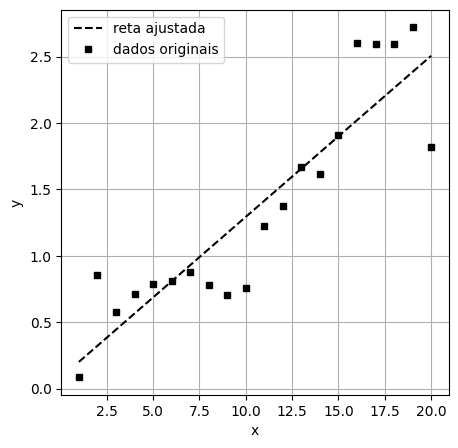

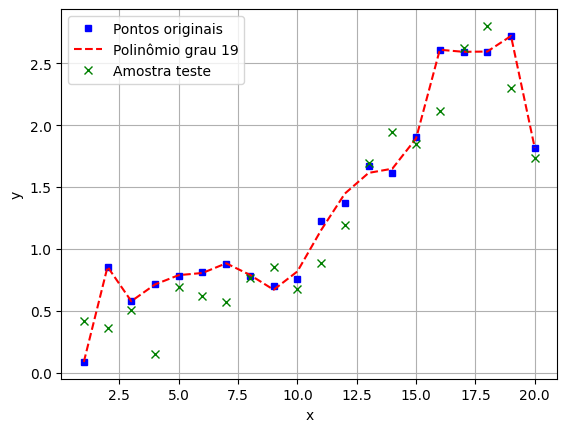

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline


#gerando x, ylearn
x = np.arange(1, 21)  # Gera um array de 1 a 20 (inclusive)
print(x)
# Calcular y usando a função polinomial
ylrn = -0.0003*x**4 + 0.0117*x**3 - 0.143*x**2 + 0.6986*x - 0.4966
# Definir seed e mostrar primeiros valores
np.random.seed(22)
# Adicionar ruído com seed 18
np.random.seed(18)
noise = np.random.normal(0, 0.2, 20)
ylrn = ylrn + noise
# Amostra teste
np.random.seed(11)
yt = -0.0003*x**4 + 0.0117*x**3 - 0.143*x**2 + 0.6986*x - 0.4966
noise_test = np.random.normal(0, 0.2, 20)
ytest = yt + noise_test

# Ajustar um polinômio de ordem 19
grau = 19
coef = np.polyfit(x, ylrn, grau)
# Calcular os valores ajustados do polinômio nos pontos x
ypol = np.polyval(coef, x)

#ajustar reta aos dados originais
# Ajustar uma reta aos pontos (x, ylrn)

modelo_linear = LinearRegression()
X_reshape = x.reshape(-1, 1)  # sklearn precisa de array 2D
modelo_linear.fit(X_reshape, ylrn)
# Fazer predições da reta
y_pred_linear = modelo_linear.predict(X_reshape)
#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
#Gráfico 1
plt.figure(figsize=(5, 5))
plt.plot(x, y_pred_linear, linestyle='--', marker="None", color='black', label='reta ajustada')
plt.plot(x, ylrn, 's', markersize=4,linestyle="none", linewidth=2, color='black',
         label='dados originais')
# Adicionar legenda e mostrar
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

#&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&
#Gráfico 2
# Plotar os dados originais
plt.plot(x, ylrn, marker='s',color='blue', linestyle="None",label='Pontos originais',markersize=4)
# Plotar a curva ajustada com linha pontilhada
plt.plot(x, ypol, linestyle='--', color='red', label=f'Polinômio grau {grau}')
# Plotar os dados de y test
plt.plot(x, ytest,  "x", color='green', label=f'Amostra teste')
# Adicionar legenda e mostrar
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()